In [1]:
from modules_modtran import modtran_utils as m_utils
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
today_date_str = datetime.now().strftime("%Y_%m_%d")

In [3]:
def get_modtran_Tb(modtran_json_path):
    m_utils.run_modtran(modtran_json_path)
    modtran_df1 = m_utils.open_tp7_file("flc_custom1.tp7")
    modtran_df2 = m_utils.open_7sc_file("flc_custom1.7sc")
    wl, Tb = 10000/modtran_df2['FREQ'], modtran_df2['BBODY_T[K]']
    freq = modtran_df2['FREQ']
    return wl, freq, Tb

In [4]:
modtran_low_cloud = "data/modtran/modtran_json/04-02_low_cloud.json"
modtran_inversion = "data/modtran/modtran_json/04-02_inversion.json"
modtran_clear = "data/modtran/modtran_json/04-02_clear_sky.json"

wl1, freq1, Tb1 = get_modtran_Tb(modtran_low_cloud)
wl2, freq2, Tb2 = get_modtran_Tb(modtran_inversion)
wl3, freq3, Tb3 = get_modtran_Tb(modtran_clear)

Tb_lines = [
    {"wl": wl1, "freq": freq1, "Tb": Tb1, "label": "Low Cloud", "color": "blue"},
    {"wl": wl2, "freq": freq2, "Tb": Tb2, "label": "Inversion", "color": "red"},
    {"wl": wl3, "freq": freq3, "Tb": Tb3, "label": "Clear Sky", "color": "green"},
]


                    *************************************************************
                    *                                                           *
                    *   MODTRAN(R) 6.0.2r3                                      *
                    *                                                           *
                    *   MODTRAN is an atmospheric radiative transfer model      *
                    *   developed collaboratively by SPECTRAL SCIENCES, INC.    *
                    *   (SSI) [www.spectral.com] and the AIR FORCE RESEARCH     *
                    *   LABORATORY (AFRL) [www.kirtland.af.mil/afrl_vs/]        *
                    *                                                           *
                    *      Please address questions and/or comments to          *
                    *      SSI at modtran@spectral.com and/or to AFRL           *
                    *      at jeannette.van_den_bosch@us.af.mil                 *
               

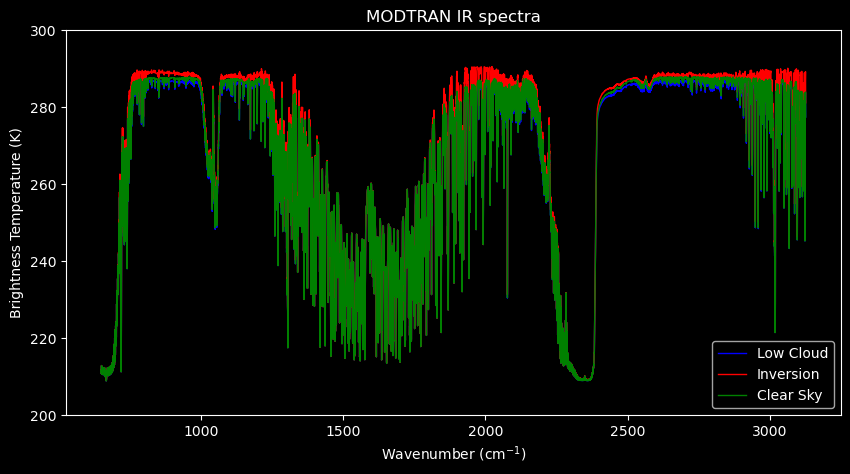

In [5]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor('black')

for line in Tb_lines:
    ax.plot(line["freq"], line["Tb"], label=line["label"], color=line["color"], linewidth=1,)

# ax.set_xlim((3,12))
ax.set_ylim((200,300))

ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Brightness Temperature (K)")
ax.set_title("MODTRAN IR spectra")
ax.legend()

plt.savefig(f"plots/{today_date_str}_modtran_ir_compare.png", dpi=300, bbox_inches='tight')
plt.show()